In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [7]:
df.loc[df['Physical_Activity_Hours'] < 0, 'Physical_Activity_Hours'] = 0

In [8]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(4998, 13)

In [12]:
for col_name in df.columns:
  print(f"Value counts for column: {col_name}")
  print(df[col_name].value_counts())
  print("\n")

Value counts for column: Age
Age
21    946
19    905
22    896
20    883
23    496
18    450
24    422
Name: count, dtype: int64


Value counts for column: Gender
Gender
Male      2634
Female    2364
Name: count, dtype: int64


Value counts for column: Country
Country
Other        1879
India         389
USA           354
Canada        230
Australia     198
             ... 
Armenia         1
Bosnia          1
Kuwait          1
Yemen           1
Syria           1
Name: count, Length: 111, dtype: int64


Value counts for column: Academic_Level
Academic_Level
Undergraduate    3630
Graduate          918
High School       450
Name: count, dtype: int64


Value counts for column: Most_Used_Platform
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64


Value counts for column: Purpose_Of_

In [13]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(exclude=np.number).columns

In [14]:
len(num_cols)

7

In [15]:
len(cat_cols)

6

In [16]:
cat_cols

Index(['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Stress_Level'],
      dtype='object')

In [17]:
num_cols

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

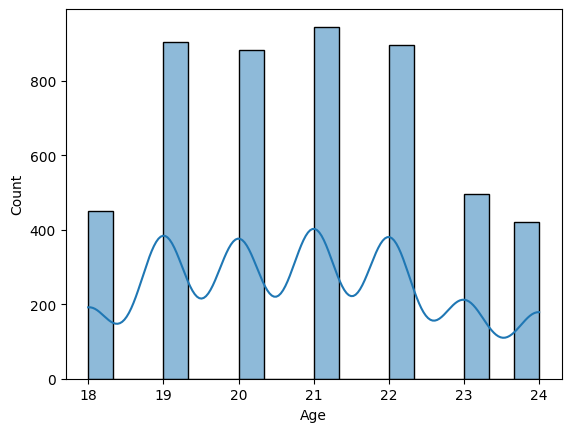

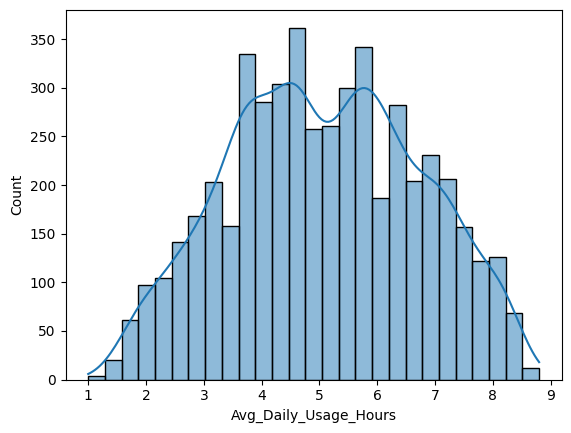

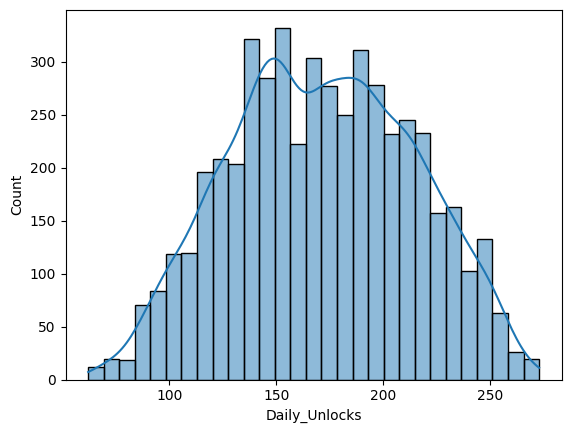

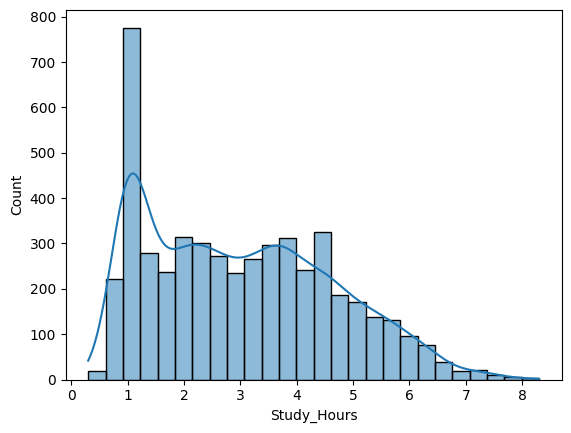

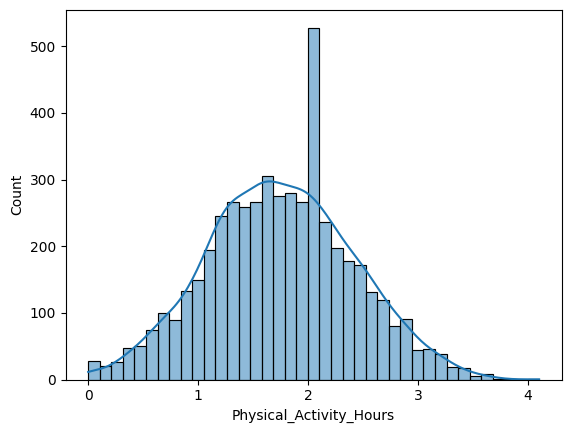

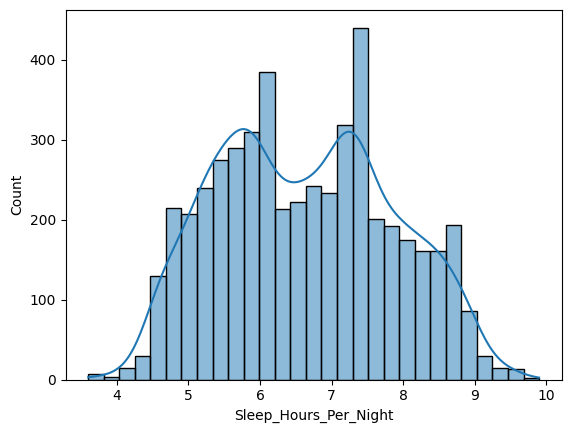

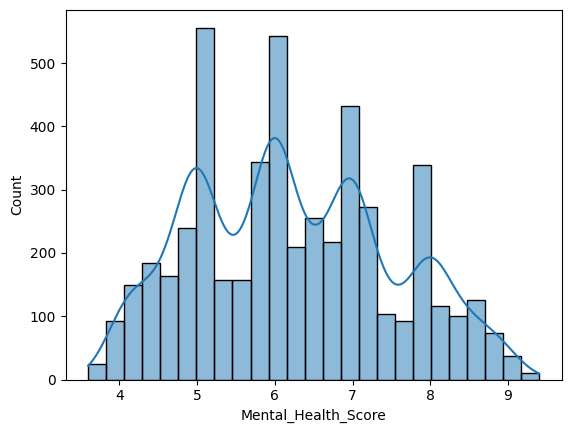

In [18]:
for col in num_cols:
  sns.histplot(df[col],kde=True)
  plt.show()

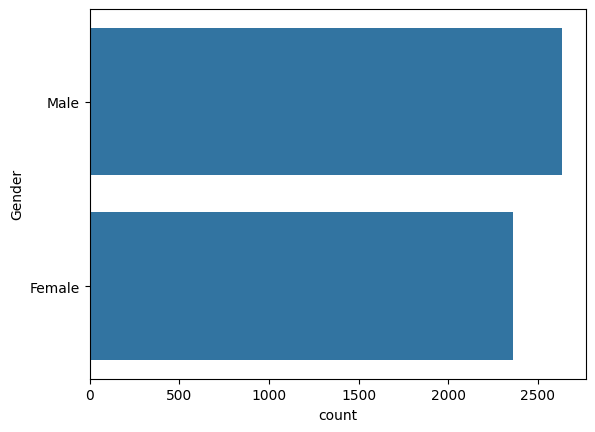

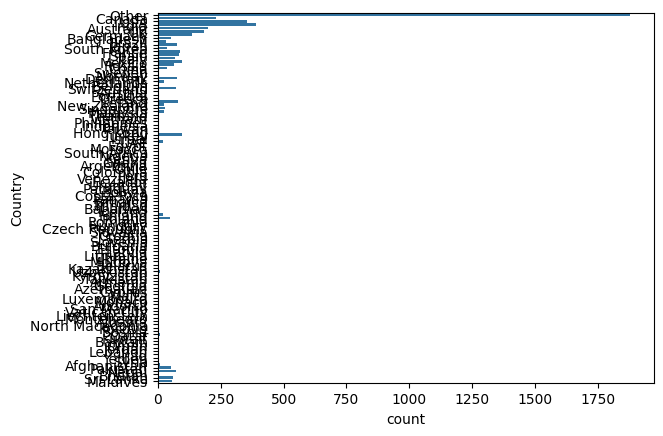

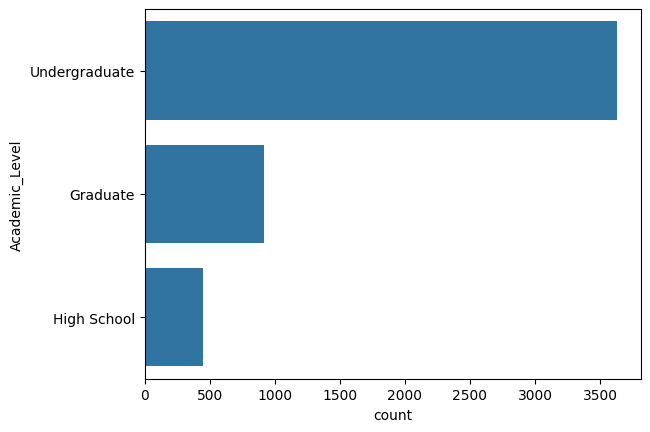

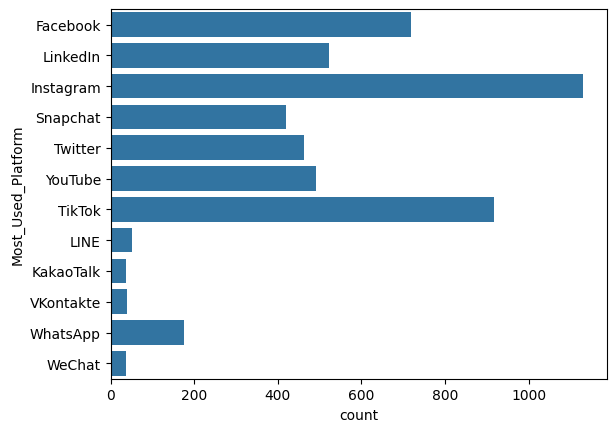

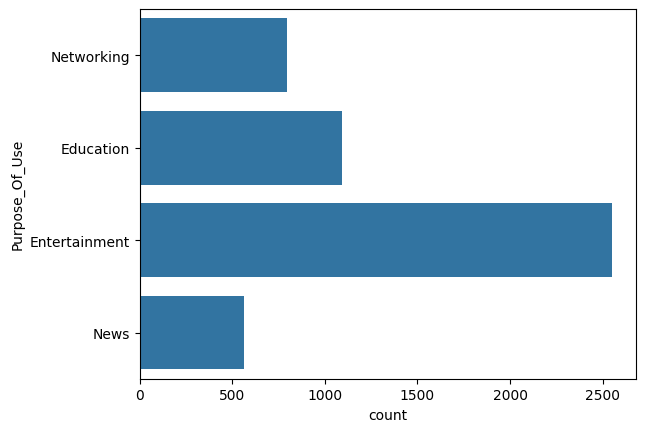

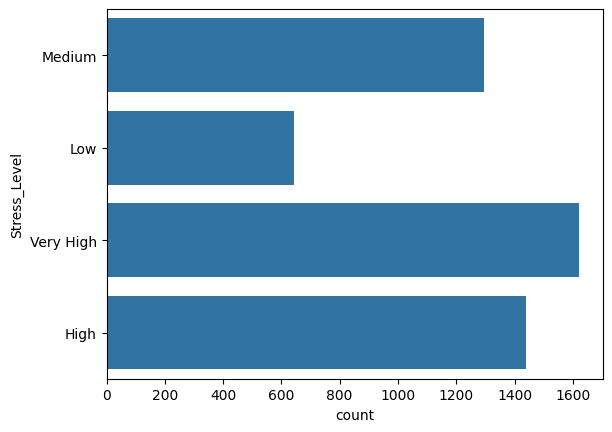

In [19]:
for col in cat_cols:
  sns.countplot(df[col])
  plt.show()

In [20]:
df = pd.get_dummies(
    df,
    columns=['Gender','Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Stress_Level','Country'],
    dtype=int
)

In [21]:
df.shape

(4998, 143)

In [22]:
df.head(10)

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Gender_Female,Gender_Male,Academic_Level_Graduate,...,Country_UAE,Country_UK,Country_USA,Country_Ukraine,Country_Uruguay,Country_Uzbekistan,Country_Vatican City,Country_Venezuela,Country_Vietnam,Country_Yemen
0,21,4.0,134,4.5,2.2,6.7,6.8,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,23,1.6,73,7.0,2.4,8.6,7.6,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,22,4.6,166,4.0,1.8,6.7,7.0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,18,7.0,220,1.0,1.7,5.4,5.3,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,24,7.5,237,1.0,1.1,5.0,4.4,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5,19,4.1,138,4.6,2.2,6.8,6.8,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,22,8.0,246,1.0,0.9,5.2,5.3,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7,21,6.0,209,1.0,1.3,5.7,4.7,1,0,0,...,0,0,0,0,0,0,0,0,0,0
8,24,4.7,154,2.4,1.1,7.0,6.2,0,1,1,...,0,0,1,0,0,0,0,0,0,0
9,19,3.6,130,3.7,1.1,8.1,8.6,0,1,0,...,0,0,0,0,0,0,0,0,0,0


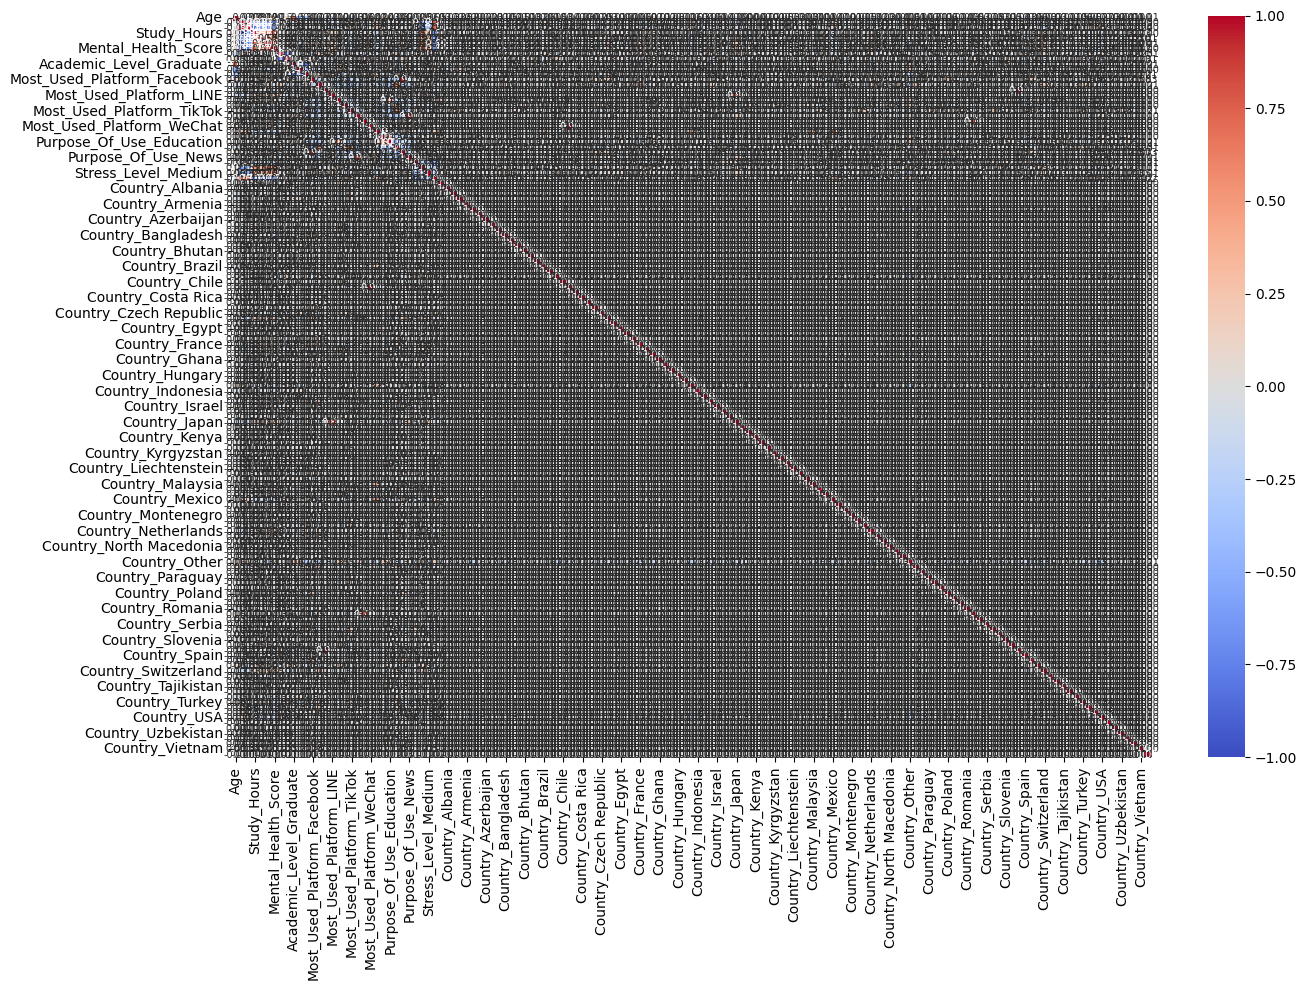

In [23]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 7}
)

plt.tight_layout()
plt.show()

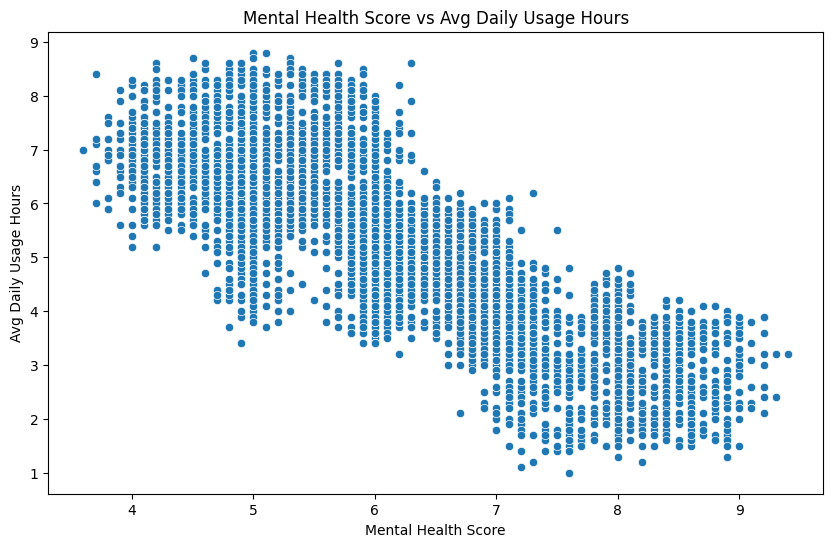

In [24]:
# mental health score vs avg daily usage hours
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mental_Health_Score', y='Avg_Daily_Usage_Hours')
plt.title('Mental Health Score vs Avg Daily Usage Hours')
plt.xlabel('Mental Health Score')
plt.ylabel('Avg Daily Usage Hours')
plt.show()

In [25]:
corr = df['Mental_Health_Score'].corr(
    df['Avg_Daily_Usage_Hours']
)

print(corr)

-0.8164851828444962


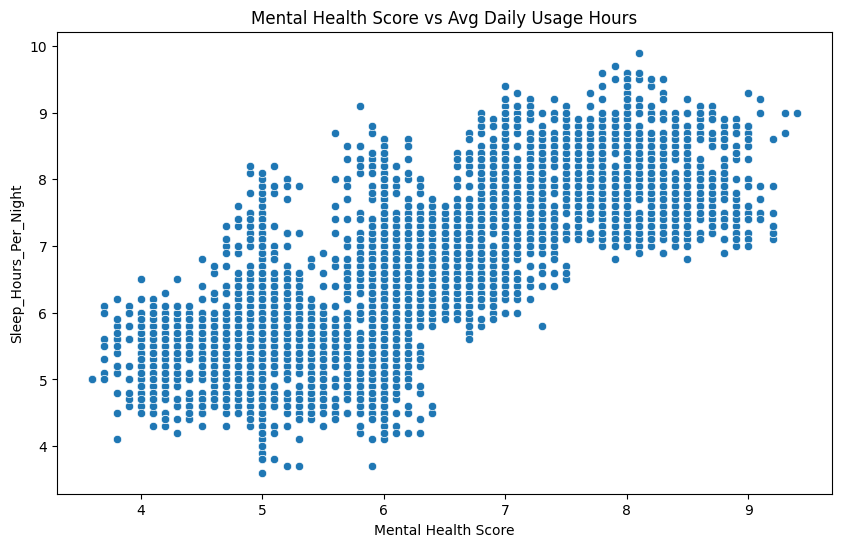

In [26]:
# mental health score vs avg daily usage hours
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mental_Health_Score', y='Sleep_Hours_Per_Night')
plt.title('Mental Health Score vs Avg Daily Usage Hours')
plt.xlabel('Mental Health Score')
plt.ylabel('Sleep_Hours_Per_Night')
plt.show()

In [27]:
corr = df['Mental_Health_Score'].corr(
    df['Sleep_Hours_Per_Night']
)

print(corr)

0.7664618129237846


In [28]:
df['Total Productive Hours']=df['Study_Hours']+df['Physical_Activity_Hours']

In [29]:
df.head()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Gender_Female,Gender_Male,Academic_Level_Graduate,...,Country_UK,Country_USA,Country_Ukraine,Country_Uruguay,Country_Uzbekistan,Country_Vatican City,Country_Venezuela,Country_Vietnam,Country_Yemen,Total Productive Hours
0,21,4.0,134,4.5,2.2,6.7,6.8,0,1,0,...,0,0,0,0,0,0,0,0,0,6.7
1,23,1.6,73,7.0,2.4,8.6,7.6,1,0,1,...,0,0,0,0,0,0,0,0,0,9.4
2,22,4.6,166,4.0,1.8,6.7,7.0,0,1,0,...,0,0,0,0,0,0,0,0,0,5.8
3,18,7.0,220,1.0,1.7,5.4,5.3,0,1,0,...,0,0,0,0,0,0,0,0,0,2.7
4,24,7.5,237,1.0,1.1,5.0,4.4,1,0,1,...,0,0,0,0,0,0,0,0,0,2.1


In [30]:
df['ratio']=df['Avg_Daily_Usage_Hours']/df['Sleep_Hours_Per_Night']

In [31]:
df.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Gender_Female', 'Gender_Male',
       'Academic_Level_Graduate',
       ...
       'Country_USA', 'Country_Ukraine', 'Country_Uruguay',
       'Country_Uzbekistan', 'Country_Vatican City', 'Country_Venezuela',
       'Country_Vietnam', 'Country_Yemen', 'Total Productive Hours', 'ratio'],
      dtype='object', length=145)

In [32]:
scale_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Study_Hours",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Total Productive Hours",
    "ratio"
]

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [34]:
df.head()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Gender_Female,Gender_Male,Academic_Level_Graduate,...,Country_USA,Country_Ukraine,Country_Uruguay,Country_Uzbekistan,Country_Vatican City,Country_Venezuela,Country_Vietnam,Country_Yemen,Total Productive Hours,ratio
0,0.102425,-0.652077,-0.873996,0.911362,0.672706,0.053499,0.444986,0,1,0,...,0,0,0,0,0,0,0,0,0.930419,-0.590172
1,1.254100,-2.103165,-2.297383,2.438856,0.972460,1.609042,1.070794,1,0,1,...,0,0,0,0,0,0,0,0,2.225042,-1.623885
2,0.678263,-0.289305,-0.127302,0.605863,0.073199,0.053499,0.601438,0,1,0,...,0,0,0,0,0,0,0,0,0.498879,-0.364921
3,-1.625088,1.161782,1.132745,-1.227130,-0.076678,-1.010819,-0.728403,0,1,0,...,0,0,0,0,0,0,0,0,-0.987540,1.168737
4,1.829938,1.464092,1.529427,-1.227130,-0.975938,-1.338302,-1.432437,1,0,1,...,0,0,0,0,0,0,0,0,-1.275234,1.681115


In [35]:
from sklearn.model_selection import train_test_split
X=df.drop('Mental_Health_Score',axis=1)
y=df['Mental_Health_Score']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [36]:
len(X_train)

3998

In [37]:
len(y_train)

3998

In [38]:
from sklearn.model_selection import KFold,cross_val_score
cv=KFold(n_splits=5,shuffle=True,random_state=42)

In [39]:
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
models={
    'LinearRegression':LinearRegression(),
    'Ridge':Ridge(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'RandomForestRegressor':RandomForestRegressor(),
    'GradientBoostingRegressor':GradientBoostingRegressor(),
    'SVR':SVR(),
    'KNeighborsRegressor':KNeighborsRegressor()
}


In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
for name , model in models.items():
  scores=cross_val_score(
      model,X_train,y_train,cv=cv,scoring='neg_mean_squared_error'
  )
  rmse_scores=np.sqrt(-scores)
  print(name)
  print("Mean CV RMSE:",rmse_scores.mean())
  print("Std CV RMSE:",rmse_scores.std())
  print()


LinearRegression
Mean CV RMSE: 0.4643700324704806
Std CV RMSE: 0.01565141513710919

Ridge
Mean CV RMSE: 0.4648147003958827
Std CV RMSE: 0.014970962280508255

DecisionTreeRegressor
Mean CV RMSE: 0.43831614783965395
Std CV RMSE: 0.014554304945407786

RandomForestRegressor
Mean CV RMSE: 0.3179943484857416
Std CV RMSE: 0.01412227208655455

GradientBoostingRegressor
Mean CV RMSE: 0.4025214545260444
Std CV RMSE: 0.014317296635689305

SVR
Mean CV RMSE: 0.36784367860072453
Std CV RMSE: 0.013428440333330736

KNeighborsRegressor
Mean CV RMSE: 0.38553989809740685
Std CV RMSE: 0.01599595210257581



In [45]:
from sklearn.model_selection import cross_validate
import numpy as np

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        return_train_score=True
    )

    train_rmse = np.sqrt(-scores["train_score"])
    val_rmse = np.sqrt(-scores["test_score"])

    print("\n", name)
    print("Mean Train RMSE:", train_rmse.mean())
    print("Mean CV RMSE:", val_rmse.mean())
    print("CV RMSE Std:", val_rmse.std())
    print("Train-CV Gap:", val_rmse.mean() - train_rmse.mean())


 LinearRegression
Mean Train RMSE: 0.45582026302356526
Mean CV RMSE: 0.4643700324704806
CV RMSE Std: 0.01565141513710919
Train-CV Gap: 0.008549769446915323

 Ridge
Mean Train RMSE: 0.4565258524441731
Mean CV RMSE: 0.4648147003958827
CV RMSE Std: 0.014970962280508255
Train-CV Gap: 0.008288847951709588

 DecisionTreeRegressor
Mean Train RMSE: 0.002388656807954313
Mean CV RMSE: 0.4372391012249258
CV RMSE Std: 0.013861982466627459
Train-CV Gap: 0.4348504444169715

 RandomForestRegressor
Mean Train RMSE: 0.1194780482974307
Mean CV RMSE: 0.3167906703240863
CV RMSE Std: 0.013772365735403675
Train-CV Gap: 0.19731262202665562

 GradientBoostingRegressor
Mean Train RMSE: 0.3803903680509673
Mean CV RMSE: 0.40255640596851683
CV RMSE Std: 0.014382972667003217
Train-CV Gap: 0.022166037917549508

 SVR
Mean Train RMSE: 0.3129795840032596
Mean CV RMSE: 0.36784367860072453
CV RMSE Std: 0.013428440333330736
Train-CV Gap: 0.05486409459746494

 KNeighborsRegressor
Mean Train RMSE: 0.29490677961830236
Mean

In [46]:
best_model=GradientBoostingRegressor()
best_model.fit(X_train,y_train)
y_pred=best_model.predict(X_test)


In [47]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2:',r2)


MAE: 0.32003132123266814
MSE: 0.1712394631825992
RMSE: 0.413810902686963
R2: 0.8432479678480647
